# Main Research Pipeline

This notebook orchestrates:
- data loading
- feature generation
- preprocessing
- baseline modeling
- walk-forward validation
- experiment logging

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import get_default_config
from src.data_utils import (
    load_market_data,
    summarize_market_data,
    get_available_fields,
    get_field_panel,
)
from src.features import (
    build_features_from_config,
    build_label_next_return,
)
from src.preprocessing import (
    preprocess_features,
    align_features_and_label,
    slice_features_by_date,
)
from src.models import (
    make_model,
    fit_model,
    fit_and_predict,
    stacked_predictions_to_panel,
)
from src.validation import run_walk_forward_validation
from src.evaluation import (
    get_hourly_risk_free_rate,
    analyze_expected_returns,
)

from src.persistence import (
    save_final_artifacts,
    load_final_artifacts,
)


from copy import deepcopy

from src.optuna_tuning import (
    tune_elastic_net_optuna,
    tune_bayesian_ridge_optuna,
)



highest without extra feautres

In [2]:
# config = get_default_config()

# config.experiment_name = "teacher_mixed_plus_oi_plus_exact_oi_xgboost_v1"

# config.features.feature_set_name = "teacher_mixed_plus_oi_plus_exact"
# config.features.raw_fields = [
#     "return",
#     "close",
#     "nb_trades",
#     "volume_usd",
#     "funding_rate",
#     "open_interest_value",
# ]
# config.features.feature_styles = [
#     "level",
#     "delta_1",
#     "delta_6",
#     "shift_1",
#     "shift_3",
#     "shift_6",
#     "shift_24",
#     "mean_6",
#     "mean_24",
#     "mean_120",
#     "std_6",
#     "std_24",
#     "std_120",
#     "skew_6",
#     "skew_24",
#     "skew_120",
#     "kurt_6",
#     "kurt_24",
#     "kurt_120",
# ]

# config.model.model_name = "xgboost"
# config.model.params = {
#     "n_estimators": 200,
#     "max_depth": 3,
#     "learning_rate": 0.05,
#     "subsample": 0.8,
#     "colsample_bytree": 0.8,
#     "reg_alpha": 0.0,
#     "reg_lambda": 1.0,
#     "objective": "reg:squarederror",
#     "random_state": config.random_seed,
#     "n_jobs": -1,
#     "tree_method": "hist",
#     "min_child_weight": 10,
#     "gamma": 0.0,
# }

# config.walk_forward.enabled = True
# config.walk_forward.retrain_frequency = "ME"
# config.walk_forward.train_window_days = 365
# config.walk_forward.validation_window_days = 31
# config.walk_forward.min_folds_before_start = 2
# config.walk_forward.prediction_delay_hours = 1

# config.evaluation.transaction_cost = 0.0
# config.evaluation.evaluation_lags = [0, 1, 2, 3, 6, 12]
# config.evaluation.plot_option = "matplotlib"

# config

In [3]:
# config = get_default_config()

# config.experiment_name = "precomputed40_plus_oi_xgboost_v1"

# # Feature choices
# config.features.feature_set_name = "precomputed_plus_oi"
# config.features.max_nb_features = 80

# config.features.raw_fields = [
#     "return",
#     "close",
#     "nb_trades",
#     "volume_usd",
#     "funding_rate",
#     "open_interest_value",
# ]
# config.features.feature_styles = [
#     "level",
#     "delta_1",
#     "delta_6",
#     "shift_1",
#     "shift_3",
#     "shift_6",
#     "shift_24",
#     "mean_6",
#     "mean_24",
#     "mean_120",
#     "std_6",
#     "std_24",
#     "std_120",
#     "skew_6",
#     "skew_24",
#     "skew_120",
#     "kurt_6",
#     "kurt_24",
#     "kurt_120",
# ]

# # Model choice
# config.model.model_name = "xgboost"
# config.model.params = {
#     "n_estimators": 200,
#     "max_depth": 3,
#     "learning_rate": 0.05,
#     "subsample": 0.8,
#     "colsample_bytree": 0.8,
#     "reg_alpha": 0.0,
#     "reg_lambda": 1.0,
#     "objective": "reg:squarederror",
#     "random_state": config.random_seed,
#     "n_jobs": -1,
#     "tree_method": "hist",
#     "min_child_weight": 10,
#     "gamma": 0.0,
# }

# # Walk-forward settings
# config.walk_forward.enabled = True
# config.walk_forward.retrain_frequency = "ME"
# config.walk_forward.train_window_days = 365
# config.walk_forward.validation_window_days = 31
# config.walk_forward.min_folds_before_start = 2
# config.walk_forward.prediction_delay_hours = 1

# # Evaluation
# config.evaluation.transaction_cost = 0.0
# config.evaluation.evaluation_lags = [0, 1, 2, 3, 6, 12]
# config.evaluation.plot_option = "matplotlib"

# config

In [4]:
# config = get_default_config()

# config.experiment_name = "precomputed80_plus_oi_elasticnet_v1"

# # Feature choices
# config.features.feature_set_name = "precomputed_plus_oi"
# config.features.max_nb_features = 80

# config.features.raw_fields = [
#     "return",
#     "close",
#     "nb_trades",
#     "volume_usd",
#     "funding_rate",
#     "open_interest_value",
# ]
# config.features.feature_styles = [
#     "level",
#     "delta_1",
#     "delta_6",
#     "shift_1",
#     "shift_3",
#     "shift_6",
#     "shift_24",
#     "mean_6",
#     "mean_24",
#     "mean_120",
#     "std_6",
#     "std_24",
#     "std_120",
#     "skew_6",
#     "skew_24",
#     "skew_120",
#     "kurt_6",
#     "kurt_24",
#     "kurt_120",
# ]

# # Model choice
# config.model.model_name = "elastic_net"
# config.model.params = {
#     "alpha": 1e-5,
#     "l1_ratio": 0.5,
#     "fit_intercept": True,
#     "tol": 2e-2,
#     "selection": "random",
#     "max_iter": 500,
#     "random_state": config.random_seed,
# }

# # Walk-forward settings
# config.walk_forward.enabled = True
# config.walk_forward.retrain_frequency = "ME"
# config.walk_forward.train_window_days = 365
# config.walk_forward.validation_window_days = 31
# config.walk_forward.min_folds_before_start = 2
# config.walk_forward.prediction_delay_hours = 1

# # Evaluation
# config.evaluation.transaction_cost = 0.0
# config.evaluation.evaluation_lags = [0, 1, 2, 3, 6, 12]
# config.evaluation.plot_option = "matplotlib"

# config

In [5]:
config = get_default_config()

config.experiment_name = "precomputed80_plus_oi_bayesian_ridge_v1"

# Feature choices
config.features.feature_set_name = "precomputed_plus_oi"
config.features.max_nb_features = 80

config.features.raw_fields = [
    "return",
    "close",
    "nb_trades",
    "volume_usd",
    "funding_rate",
    "open_interest_value",
]
config.features.feature_styles = [
    "level",
    "delta_1",
    "delta_6",
    "shift_1",
    "shift_3",
    "shift_6",
    "shift_24",
    "mean_6",
    "mean_24",
    "mean_120",
    "std_6",
    "std_24",
    "std_120",
    "skew_6",
    "skew_24",
    "skew_120",
    "kurt_6",
    "kurt_24",
    "kurt_120",
]

# Model choice
config.model.model_name = "bayesian_ridge"
config.model.params = {
    "max_iter": 300,
    "tol": 1e-3,
    "alpha_1": 1e-6,
    "alpha_2": 1e-6,
    "lambda_1": 1e-6,
    "lambda_2": 1e-6,
    "fit_intercept": True,
    "copy_X": True,
    "verbose": False,
}

# Walk-forward settings
config.walk_forward.enabled = True
config.walk_forward.retrain_frequency = "ME"
config.walk_forward.train_window_days = 365
config.walk_forward.validation_window_days = 31
config.walk_forward.min_folds_before_start = 2
config.walk_forward.prediction_delay_hours = 1

# Evaluation
config.evaluation.transaction_cost = 0.0
config.evaluation.evaluation_lags = [0, 1, 2, 3, 6, 12]
config.evaluation.plot_option = "matplotlib"

config

ExperimentConfig(experiment_name='precomputed80_plus_oi_bayesian_ridge_v1', random_seed=0, paths=PathsConfig(data_dir='data/all/', artifacts_dir='artifacts', results_dir='results', in_sample_filename='data_in_sample.csv', test_filename='data_test.csv'), data=DataConfig(datetime_col=None, index_col=0, header_rows=[0, 1]), dates=DateConfig(start_date_train='2023-01-24', last_date_train='2024-01-24', start_date_validate='2024-01-25', last_date_validate='2024-07-24'), evaluation=EvalConfig(risk_free_rate_annual=0.05, transaction_cost=0.0, evaluation_lags=[0, 1, 2, 3, 6, 12], plot_option='matplotlib', annualization_factor=8760), features=FeatureConfig(feature_set_name='precomputed_plus_oi', raw_fields=['return', 'close', 'nb_trades', 'volume_usd', 'funding_rate', 'open_interest_value'], feature_styles=['level', 'delta_1', 'delta_6', 'shift_1', 'shift_3', 'shift_6', 'shift_24', 'mean_6', 'mean_24', 'mean_120', 'std_6', 'std_24', 'std_120', 'skew_6', 'skew_24', 'skew_120', 'kurt_6', 'kurt_24'

In [6]:
config_path = f"artifacts/{config.experiment_name}_config.json"
config.to_json(config_path)

print(f"Saved config to: {config_path}")

Saved config to: artifacts/precomputed80_plus_oi_bayesian_ridge_v1_config.json


In [7]:
data = load_market_data(
    filepath=f"{config.paths.data_dir}/{config.paths.in_sample_filename}",
    index_col=config.data.index_col,
    header_rows=config.data.header_rows,
)

summary = summarize_market_data(data)
display(summary)

n_timestamps                     13152
n_columns_total                   4521
n_fields                            11
n_instruments                      411
start_date         2023-01-24 00:00:00
end_date           2024-07-24 23:00:00
dtype: object

In [8]:
fields = get_available_fields(data)
print("Available fields:")
print(fields)

returns_panel = get_field_panel(data, "return")
print("\nReturns panel shape:", returns_panel.shape)

returns_panel.head()

Available fields:
['open', 'high', 'low', 'close', 'nb_trades', 'volume_coin', 'volume_usd', 'open_interest', 'open_interest_value', 'funding_rate', 'return']

Returns panel shape: (13152, 411)


,VANRY,EGLD,BTS,KEY,HIPPO,FRONT,BLZ,ETH,USUAL,MEME,...,CKB,ATOM,AUCTION,ARKM,POPCAT,PNUT,SPX,AXS,YFI,MDT
2023-01-24 00:00:00,NaN,-0.006325,NaN,NaN,NaN,NaN,0.002640,-0.000792,NaN,NaN,...,NaN,-0.004116,NaN,NaN,NaN,NaN,NaN,-0.013171,-0.001795,NaN
2023-01-24 01:00:00,NaN,-0.002501,NaN,NaN,NaN,NaN,-0.008591,0.003331,NaN,NaN,...,NaN,0.002296,NaN,NaN,NaN,NaN,NaN,-0.025383,0.002440,NaN
2023-01-24 02:00:00,NaN,0.009799,NaN,NaN,NaN,NaN,0.019287,0.003878,NaN,NaN,...,NaN,0.008781,NaN,NaN,NaN,NaN,NaN,0.007645,0.014092,NaN
2023-01-24 03:00:00,NaN,0.000451,NaN,NaN,NaN,NaN,-0.006445,-0.001733,NaN,NaN,...,NaN,0.005147,NaN,NaN,NaN,NaN,NaN,0.000000,-0.000253,NaN
2023-01-24 04:00:00,NaN,0.002481,NaN,NaN,NaN,NaN,0.014905,0.002292,NaN,NaN,...,NaN,0.006401,NaN,NaN,NaN,NaN,NaN,0.014424,0.006065,NaN


In [9]:
features = build_features_from_config(data, config.features)

print("Raw feature matrix shape:", features.shape)
display(features.head())

Raw feature matrix shape: (2858559, 90)


feature_007635434513  feature_018035121479  \
2023-01-24 EGLD                   NaN             -0.001321   
           BLZ                    NaN              0.003475   
           ETH                    NaN             -0.001033   
           AAVE                   NaN             -0.002450   
           ALGO                   NaN             -0.024983   

                 feature_025508110388  feature_036951734703  \
2023-01-24 EGLD             -0.145652             -0.187734   
           BLZ              -0.144913             -0.284642   
           ETH              -0.201304             -0.130641   
           AAVE              0.271077              0.197250   
           ALGO              0.049205             -0.258745   

                 feature_047776260277  feature_057360205173  \
2023-01-24 EGLD              0.007202              0.459644   
           BLZ               0.027423             -0.651226   
           ETH               0.024719              0.301675   
           AAVE              0.004592              0.505541   
           ALGO              0.030821              0.127595   

                 feature_064246337850  feature_074605339490  \
2023-01-24 EGLD              0.001863              0.021209   
           BLZ              -0.001656              0.017391   
           ETH               0.004762             -0.007861   
           AAVE              0.002070             -0.018447   
           ALGO             -0.001242             -0.012483   

                 feature_087704804572  feature_124203207590  ...  \
2023-01-24 EGLD              0.000022             -0.042802  ...   
           BLZ               0.000113              0.010565  ...   
           ETH               0.000085              0.005885  ...   
           AAVE              0.000111             -0.018401  ...   
           ALGO             -0.000067              0.018029  ...   

                 alpha_oi_delta_1_rev  alpha_oi_delta_6_rev  \
2023-01-24 EGLD                   NaN                   NaN   
           BLZ                    NaN                   NaN   
           ETH                    NaN                   NaN   
           AAVE                   NaN                   NaN   
           ALGO                   NaN                   NaN   

                 alpha_oi_value_delta_1_rev  alpha_oi_value_delta_6_rev  \
2023-01-24 EGLD                         NaN                         NaN   
           BLZ                          NaN                         NaN   
           ETH                          NaN                         NaN   
           AAVE                         NaN                         NaN   
           ALGO                         NaN                         NaN   

                 alpha_oi_value_level_rev  alpha_oi_value_dist_mean_rev  \
2023-01-24 EGLD             -1.276026e+07                          -1.0   
           BLZ              -3.613338e+06                          -1.0   
           ETH              -1.749468e+09                          -1.0   
           AAVE             -2.554519e+07                          -1.0   
           ALGO             -1.349624e+07                          -1.0   

                 alpha_oi_value_zscore_rev  alpha_oi_zscore_rev  \
2023-01-24 EGLD                        NaN                  NaN   
           BLZ                         NaN                  NaN   
           ETH                         NaN                  NaN   
           AAVE                        NaN                  NaN   
           ALGO                        NaN                  NaN   

                 alpha_oi_value_macd_rev  alpha_oi_macd_rev  
2023-01-24 EGLD                     -0.0               -0.0  
           BLZ                      -0.0               -0.0  
           ETH                      -0.0               -0.0  
           AAVE                     -0.0               -0.0  
           ALGO                     -0.0               -0.0  

[5 rows x 90 columns]

In [10]:
features_processed = preprocess_features(features, config.preprocessing)

print("Processed feature matrix shape:", features_processed.shape)
display(features_processed.head())

Processed feature matrix shape: (2858559, 90)


feature_007635434513  feature_018035121479  \
2023-01-24 EGLD                   0.0              0.092686   
           BLZ                    0.0              0.671970   
           ETH                    0.0              0.115857   
           AAVE                   0.0             -0.069514   
           ALGO                   0.0             -1.552482   

                 feature_025508110388  feature_036951734703  \
2023-01-24 EGLD             -0.932164             -0.932164   
           BLZ              -0.906971             -1.385650   
           ETH              -1.158907             -0.579454   
           AAVE              1.511618              1.410843   
           ALGO              0.503873             -1.234488   

                 feature_047776260277  feature_057360205173  \
2023-01-24 EGLD             -0.625627              1.184101   
           BLZ               1.251254             -1.083326   
           ETH               0.950026              0.982552   
           AAVE             -0.741484              1.209294   
           ALGO              1.436625              0.327517   

                 feature_064246337850  feature_074605339490  \
2023-01-24 EGLD              0.223492              1.367111   
           BLZ              -0.198659              1.274426   
           ETH               0.571146             -0.741484   
           AAVE              0.248324             -1.413454   
           ALGO             -0.148995             -0.996369   

                 feature_087704804572  feature_124203207590  ...  \
2023-01-24 EGLD             -0.258341             -1.251254  ...   
           BLZ               0.634110              0.579284  ...   
           ETH               0.469711              0.347571  ...   
           AAVE              0.610625             -0.579284  ...   
           ALGO             -0.892452              0.950026  ...   

                 alpha_oi_delta_1_rev  alpha_oi_delta_6_rev  \
2023-01-24 EGLD                   0.0                   0.0   
           BLZ                    0.0                   0.0   
           ETH                    0.0                   0.0   
           AAVE                   0.0                   0.0   
           ALGO                   0.0                   0.0   

                 alpha_oi_value_delta_1_rev  alpha_oi_value_delta_6_rev  \
2023-01-24 EGLD                         0.0                         0.0   
           BLZ                          0.0                         0.0   
           ETH                          0.0                         0.0   
           AAVE                         0.0                         0.0   
           ALGO                         0.0                         0.0   

                 alpha_oi_value_level_rev  alpha_oi_value_dist_mean_rev  \
2023-01-24 EGLD                 -0.625627                           0.0   
           BLZ                   1.158569                           0.0   
           ETH                  -1.691511                           0.0   
           AAVE                 -0.973198                           0.0   
           ALGO                 -0.695141                           0.0   

                 alpha_oi_value_zscore_rev  alpha_oi_zscore_rev  \
2023-01-24 EGLD                        0.0                  0.0   
           BLZ                         0.0                  0.0   
           ETH                         0.0                  0.0   
           AAVE                        0.0                  0.0   
           ALGO                        0.0                  0.0   

                 alpha_oi_value_macd_rev  alpha_oi_macd_rev  
2023-01-24 EGLD                      0.0                0.0  
           BLZ                       0.0                0.0  
           ETH                       0.0                0.0  
           AAVE                      0.0                0.0  
           ALGO                      0.0                0.0  

[5 rows x 90 columns]

In [11]:
config_path = f"artifacts/{config.experiment_name}_config.json"
config.to_json(config_path)
print(f"Saved tuned config to: {config_path}")

Saved tuned config to: artifacts/precomputed80_plus_oi_bayesian_ridge_v1_config.json


In [12]:
label_train = build_label_next_return(
    data=data,
    start_date=config.dates.start_date_train,
    end_date=config.dates.last_date_train,
)

print("Training label shape:", label_train.shape)
display(label_train.head())

Training label shape: (1716459,)


2023-01-24  EGLD   -0.002501
            BLZ    -0.008591
            ETH     0.003331
            AAVE    0.000000
            ALGO    0.009608
Name: label_next_return, dtype: float64

In [13]:
X_train, y_train = align_features_and_label(features_processed, label_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1716357, 90)
y_train shape: (1716357,)


In [14]:
X_validate = slice_features_by_date(
    features_processed,
    start_date=config.dates.start_date_validate,
    end_date=config.dates.last_date_validate,
)

print("X_validate shape:", X_validate.shape)
display(X_validate.head())

X_validate shape: (1135948, 90)


feature_007635434513  feature_018035121479  \
2024-01-25 EGLD               0.007647              0.391899   
           KEY               -0.909998             -0.321917   
           FRONT             -0.160588             -1.301666   
           BLZ               -0.237058              0.951755   
           ETH                0.022941             -0.685824   

                  feature_025508110388  feature_036951734703  \
2024-01-25 EGLD               1.600554             -0.588526   
           KEY               -0.758948             -0.514029   
           FRONT             -0.713862              0.037248   
           BLZ                1.119636              0.052148   
           ETH               -0.082658              1.080206   

                  feature_047776260277  feature_057360205173  \
2024-01-25 EGLD               0.797795             -1.360095   
           KEY               -0.335914             -0.488432   
           FRONT             -1.385643             -0.187858   
           BLZ               -1.525607             -1.209808   
           ETH               -0.181953             -0.683805   

                  feature_064246337850  feature_074605339490  \
2024-01-25 EGLD              -0.500126             -0.041989   
           KEY                1.162058              1.147705   
           FRONT              1.117929              0.181953   
           BLZ                1.647475             -0.741809   
           ETH                0.720770             -0.405896   

                  feature_087704804572  feature_124203207590  ...  \
2024-01-25 EGLD              -0.274037              1.581593  ...   
           KEY               -0.639420              0.447885  ...   
           FRONT              1.426398              1.259676  ...   
           BLZ               -1.398291             -0.853780  ...   
           ETH               -1.075068             -1.105715  ...   

                  alpha_oi_delta_1_rev  alpha_oi_delta_6_rev  \
2024-01-25 EGLD               1.245679             -1.315661   
           KEY               -1.147705             -1.119712   
           FRONT              1.049730              0.363906   
           BLZ               -0.251935              1.007741   
           ETH               -0.937759              0.293924   

                  alpha_oi_value_delta_1_rev  alpha_oi_value_delta_6_rev  \
2024-01-25 EGLD                     1.259676                   -0.755806   
           KEY                     -1.175697                   -1.385643   
           FRONT                    0.321917                    0.153960   
           BLZ                      0.335914                    1.693564   
           ETH                     -0.405896                    0.699820   

                  alpha_oi_value_level_rev  alpha_oi_value_dist_mean_rev  \
2024-01-25 EGLD                  -0.321917                      1.147705   
           KEY                    0.853780                     -1.175697   
           FRONT                  0.559856                      0.629838   
           BLZ                   -1.273672                      0.755806   
           ETH                   -1.707561                      0.027993   

                  alpha_oi_value_zscore_rev  alpha_oi_zscore_rev  \
2024-01-25 EGLD                   -0.545860            -1.287669   
           KEY                    -1.623582            -1.147705   
           FRONT                   0.517867            -0.601845   
           BLZ                     1.273672             0.657831   
           ETH                     0.769802             0.181953   

                  alpha_oi_value_macd_rev  alpha_oi_macd_rev  
2024-01-25 EGLD                 -1.399640          -1.623582  
           KEY                  -0.797795          -0.321917  
           FRONT                -0.377903          -0.993744  
           BLZ                   1.637579           0.909766  
           ETH                   0.68582

In [15]:
stacked_preds_baseline = fit_and_predict(
    model_config=config.model,
    X_train=X_train,
    y_train=y_train,
    X_predict=X_validate,
)

pred_panel_baseline = stacked_predictions_to_panel(stacked_preds_baseline)

print("Stacked baseline predictions shape:", stacked_preds_baseline.shape)
print("Panel baseline predictions shape:", pred_panel_baseline.shape)

display(stacked_preds_baseline.head())

Stacked baseline predictions shape: (1135948,)
Panel baseline predictions shape: (4345, 282)


2024-01-25  EGLD     0.000342
            KEY     -0.000128
            FRONT    0.000082
            BLZ     -0.000141
            ETH     -0.000132
Name: prediction, dtype: float64

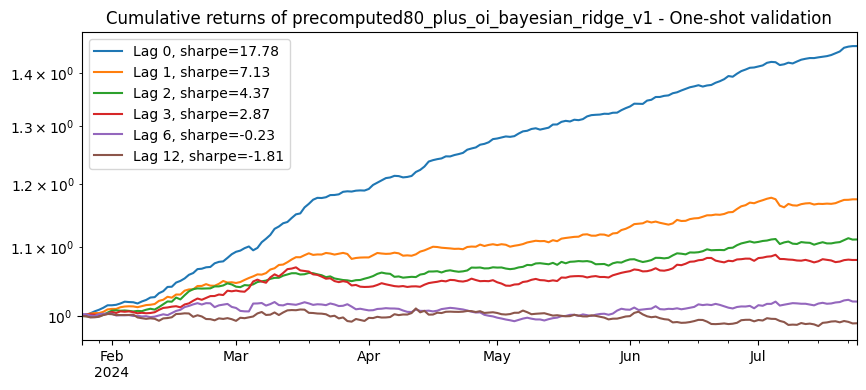

,turnover,sharpe
Statistics,11.35,17.78


In [16]:
rfr_hourly = get_hourly_risk_free_rate(config.evaluation.risk_free_rate_annual)

baseline_stats = analyze_expected_returns(
    expected_returns=pred_panel_baseline,
    returns=returns_panel.loc[
        config.dates.start_date_validate:config.dates.last_date_validate
    ],
    rfr_hourly=rfr_hourly,
    title=f"{config.experiment_name} - One-shot validation",
    lags=config.evaluation.evaluation_lags,
    tc=config.evaluation.transaction_cost,
    plot_option=config.evaluation.plot_option,
    output_stats=True,
)

display(baseline_stats)

In [17]:
wf_results = run_walk_forward_validation(
    data=data,
    features_processed=features_processed,
    config=config,
    verbose=True,
)

Train: 2022-03-31 00:00:00 -> 2023-03-31 00:00:00
Predict: 2023-03-31 01:00:00 -> 2023-05-01 00:00:00

Train: 2022-04-30 00:00:00 -> 2023-04-30 00:00:00
Predict: 2023-04-30 01:00:00 -> 2023-05-31 00:00:00

Train: 2022-05-31 00:00:00 -> 2023-05-31 00:00:00
Predict: 2023-05-31 01:00:00 -> 2023-07-01 00:00:00

Train: 2022-06-30 00:00:00 -> 2023-06-30 00:00:00
Predict: 2023-06-30 01:00:00 -> 2023-07-31 00:00:00

Train: 2022-07-31 00:00:00 -> 2023-07-31 00:00:00
Predict: 2023-07-31 01:00:00 -> 2023-08-31 00:00:00

Train: 2022-08-31 00:00:00 -> 2023-08-31 00:00:00
Predict: 2023-08-31 01:00:00 -> 2023-10-01 00:00:00

Train: 2022-09-30 00:00:00 -> 2023-09-30 00:00:00
Predict: 2023-09-30 01:00:00 -> 2023-10-31 00:00:00

Train: 2022-10-31 00:00:00 -> 2023-10-31 00:00:00
Predict: 2023-10-31 01:00:00 -> 2023-12-01 00:00:00

Train: 2022-11-30 00:00:00 -> 2023-11-30 00:00:00
Predict: 2023-11-30 01:00:00 -> 2023-12-31 00:00:00

Train: 2022-12-31 00:00:00 -> 2023-12-31 00:00:00
Predict: 2023-12-31 01:

In [18]:
display(wf_results["fold_details"])

,last_date_train_fold,start_date_train_fold,start_date_validate_fold,last_date_validate_fold,n_train_rows,n_validate_rows
0,2023-03-31,2022-03-31,2023-03-31 01:00:00,2023-05-01,253464,129665
1,2023-04-30,2022-04-30,2023-04-30 01:00:00,2023-05-31,378890,135180
2,2023-05-31,2022-05-31,2023-05-31 01:00:00,2023-07-01,514062,137084
3,2023-06-30,2022-06-30,2023-06-30 01:00:00,2023-07-31,646668,140064
4,2023-07-31,2022-07-31,2023-07-31 01:00:00,2023-08-31,786726,145525
5,2023-08-31,2022-08-31,2023-08-31 01:00:00,2023-10-01,932245,148306
6,2023-09-30,2022-09-30,2023-09-30 01:00:00,2023-10-31,1075674,154560
7,2023-10-31,2022-10-31,2023-10-31 01:00:00,2023-12-01,1230222,168628
8,2023-11-30,2022-11-30,2023-11-30 01:00:00,2023-12-31,1393189,177051
9,2023-12-31,2022-12-31,2023-12-31 01:00:00,2024-01-31,1570233,182202


Walk-forward prediction panel shape: (11567, 284)


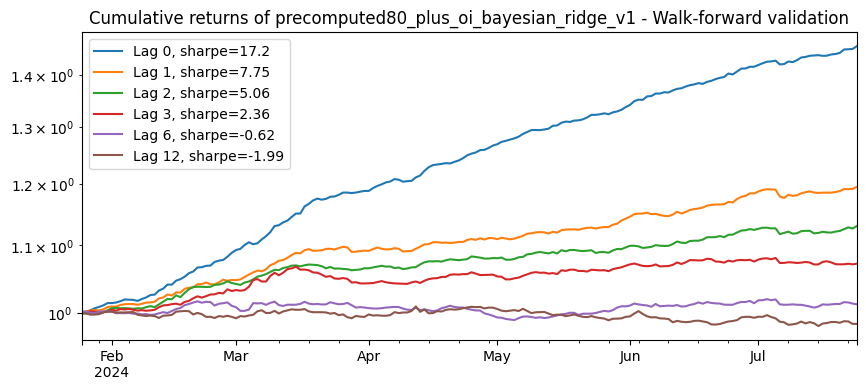

,turnover,sharpe
Statistics,10.81,17.2


In [19]:
wf_pred_panel = wf_results["predictions_panel"]

print("Walk-forward prediction panel shape:", wf_pred_panel.shape)

wf_stats = analyze_expected_returns(
    expected_returns=wf_pred_panel.loc[
        config.dates.start_date_validate:config.dates.last_date_validate
    ],
    returns=returns_panel.loc[
        config.dates.start_date_validate:config.dates.last_date_validate
    ],
    rfr_hourly=rfr_hourly,
    title=f"{config.experiment_name} - Walk-forward validation",
    lags=config.evaluation.evaluation_lags,
    tc=config.evaluation.transaction_cost,
    plot_option=config.evaluation.plot_option,
    output_stats=True,
)

display(wf_stats)

In [20]:
comparison = pd.concat(
    {
        "one_shot_validation": baseline_stats.iloc[0],
        "walk_forward_validation": wf_stats.iloc[0],
    },
    axis=1,
).T

display(comparison)

,turnover,sharpe
one_shot_validation,11.35,17.78
walk_forward_validation,10.81,17.20


In [21]:
run_summary = {
    "experiment_name": config.experiment_name,
    "model_name": config.model.model_name,
    "feature_set_name": config.features.feature_set_name,
    "n_features": features_processed.shape[1],
    "one_shot_sharpe_lag0": baseline_stats.loc["Statistics", "sharpe"],
    "one_shot_turnover": baseline_stats.loc["Statistics", "turnover"],
    "walk_forward_sharpe_lag0": wf_stats.loc["Statistics", "sharpe"],
    "walk_forward_turnover": wf_stats.loc["Statistics", "turnover"],
}

run_summary

{'experiment_name': 'precomputed80_plus_oi_bayesian_ridge_v1',
 'model_name': 'bayesian_ridge',
 'feature_set_name': 'precomputed_plus_oi',
 'n_features': 90,
 'one_shot_sharpe_lag0': np.float64(17.78),
 'one_shot_turnover': np.float64(11.35),
 'walk_forward_sharpe_lag0': np.float64(17.2),
 'walk_forward_turnover': np.float64(10.81)}

In [22]:
run_summary_df = pd.DataFrame([run_summary])

summary_path = "results/run_summaries.csv"

try:
    existing = pd.read_csv(summary_path)
    updated = pd.concat([existing, run_summary_df], ignore_index=True)
except FileNotFoundError:
    updated = run_summary_df.copy()

updated.to_csv(summary_path, index=False)

print(f"Saved run summary to: {summary_path}")
display(updated.tail())

Saved run summary to: results/run_summaries.csv


,experiment_name,model_name,feature_set_name,n_features,one_shot_sharpe_lag0,one_shot_turnover,walk_forward_sharpe_lag0,walk_forward_turnover
24,precomputed80_plus_oi_elasticnet_v1,elastic_net,precomputed_plus_oi,90,17.17,11.60,17.5,10.91
25,precomputed80_plus_oi_bayesian_ridge_v1,bayesian_ridge,precomputed_plus_oi,90,17.78,11.35,17.2,10.81
26,precomputed80_plus_oi_stack_en_xgb_rankavg_v1,stack_en_xgb_rankavg,precomputed_plus_oi,90,NaN,NaN,15.5,10.78
27,precomputed80_plus_oi_optuna_base,elastic_net,precomputed_plus_oi,90,17.17,11.60,17.5,10.91
28,precomputed80_plus_oi_bayesian_ridge_v1,bayesian_ridge,precomputed_plus_oi,90,17.78,11.35,17.2,10.81


In [23]:
final_model = make_model(config.model)
final_model = fit_model(final_model, X_train, y_train)

final_metrics = {
    "one_shot_sharpe_lag0": baseline_stats.loc["Statistics", "sharpe"],
    "one_shot_turnover": baseline_stats.loc["Statistics", "turnover"],
    "walk_forward_sharpe_lag0": wf_stats.loc["Statistics", "sharpe"],
    "walk_forward_turnover": wf_stats.loc["Statistics", "turnover"],
}

artifact_paths = save_final_artifacts(
    model=final_model,
    config=config,
    feature_columns=features_processed.columns.tolist(),
    experiment_name=config.experiment_name,
    artifacts_dir=config.paths.artifacts_dir,
    metrics=final_metrics,
)

artifact_paths

{'run_dir': 'artifacts/precomputed80_plus_oi_bayesian_ridge_v1',
 'model_path': 'artifacts/precomputed80_plus_oi_bayesian_ridge_v1/model.joblib',
 'config_path': 'artifacts/precomputed80_plus_oi_bayesian_ridge_v1/config.json',
 'feature_columns_path': 'artifacts/precomputed80_plus_oi_bayesian_ridge_v1/feature_columns.json',
 'metadata_path': 'artifacts/precomputed80_plus_oi_bayesian_ridge_v1/metadata.json'}